# Marine 48h Forecast — v9: ZIDF-Inspired Diffusion Model for All 6 Hard Parameters

A ninth attempt, all 6 hard parameters (visibility ×4, precipitation ×2), inspired by
[ZIDF (Zero Inflation Diffusion Framework)](https://github.com/Wentao-Gao/ZIDF-from-noise-to-precision)
— "From Noise to Precision: A Diffusion-Driven Approach to Zero-Inflated Precipitation Prediction"
(2025), which has real public code (unlike DET in v6, which only had an abstract).

**Why diffusion, specifically — the mechanism this is actually testing:** every point-estimate model
tried so far (v1-v8) computes one deterministic number per forecast step. For rare-event series, the
statistically "safest" single number is whatever minimizes expected error — which for these 6
parameters means predicting close to the unconditional mean/median, i.e. close to never predicting
the rare event at all. v4 (visibility) and v6/v7 (precipitation) both failed by collapsing toward that
safe average. A **diffusion model is generative**: it samples whole plausible trajectories rather than
computing one number, and the **median of many samples** can correctly land on the rare-event value
when the sampled trajectories actually capture that possibility — a structurally different way to
escape the same collapse, rather than another loss function or architecture tweak.

**Adapted per group, same pattern as v6:** ZIDF's published architecture is specifically for
zero-inflated precipitation (Gaussian perturbation of the zero/positive boundary, diffusion-based
restoration of exact zeros). Visibility isn't zero-inflated, so it skips the zero-perturbation step
and uses plain continuous diffusion instead — same backbone, same training/sampling procedure, the
data-specific step turned off where it doesn't apply.

Univariate per parameter (6 independent small models), consistent with this project's repeated finding
that cross-channel mixing hurts these 6 specifically. Standalone — does not modify any other notebook,
dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS

LOOKBACK, HORIZON = 288, 288
idx = df_10min.index
calendar_df = pd.DataFrame({
    "hour_sin": np.sin(2 * np.pi * idx.hour / 24), "hour_cos": np.cos(2 * np.pi * idx.hour / 24),
    "dom_sin": np.sin(2 * np.pi * idx.day / 30), "dom_cos": np.cos(2 * np.pi * idx.day / 30),
}, index=idx)
calendar_cols = list(calendar_df.columns)

train_df = df_10min.iloc[:-HORIZON]
test_df = df_10min.iloc[-HORIZON:]
train_calendar = calendar_df.iloc[:-HORIZON]
test_calendar = calendar_df.iloc[-HORIZON:]
print(f"Train: {train_df.shape[0]} rows  |  Test: {test_df.shape[0]} rows")

Train: 4032 rows  |  Test: 288 rows


## 2. Diffusion model: conditioning encoder + MLP noise-predictor, DDPM training/sampling

In [3]:
N_DIFFUSION_STEPS = 50
BETA_START, BETA_END = 1e-4, 0.02

betas = torch.linspace(BETA_START, BETA_END, N_DIFFUSION_STEPS)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(half, dtype=torch.float32) / half)
    args = t.float().unsqueeze(-1) * freqs.unsqueeze(0)
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)


class CondEncoder(nn.Module):
    def __init__(self, lookback, n_calendar, d_model=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(lookback * (1 + n_calendar), 128), nn.GELU(),
            nn.Linear(128, d_model),
        )

    def forward(self, x_target, x_calendar):
        B = x_target.shape[0]
        x = torch.cat([x_target, x_calendar], dim=-1).reshape(B, -1)
        return self.net(x)


class DenoiseMLP(nn.Module):
    def __init__(self, horizon, cond_dim=64, temb_dim=64, hidden=256):
        super().__init__()
        self.temb_dim = temb_dim
        self.net = nn.Sequential(
            nn.Linear(horizon + cond_dim + temb_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, horizon),
        )

    def forward(self, y_t, cond, t):
        temb = timestep_embedding(t, self.temb_dim)
        x = torch.cat([y_t, cond, temb], dim=-1)
        return self.net(x)


class DiffusionForecaster(nn.Module):
    def __init__(self, lookback, horizon, n_calendar, d_model=64):
        super().__init__()
        self.cond_encoder = CondEncoder(lookback, n_calendar, d_model)
        self.denoiser = DenoiseMLP(horizon, cond_dim=d_model, temb_dim=d_model)
        self.horizon = horizon

    def training_loss(self, x_target, x_calendar, y0):
        B = y0.shape[0]
        cond = self.cond_encoder(x_target, x_calendar)
        t = torch.randint(0, N_DIFFUSION_STEPS, (B,))
        a_bar = alphas_cumprod[t].unsqueeze(-1)
        noise = torch.randn_like(y0)
        y_t = torch.sqrt(a_bar) * y0 + torch.sqrt(1 - a_bar) * noise
        pred_noise = self.denoiser(y_t, cond, t)
        return ((pred_noise - noise) ** 2).mean()

    @torch.no_grad()
    def sample(self, x_target, x_calendar, n_samples=30):
        cond = self.cond_encoder(x_target, x_calendar)
        cond = cond.repeat(n_samples, 1)
        y = torch.randn(n_samples, self.horizon)
        for step in reversed(range(N_DIFFUSION_STEPS)):
            t = torch.full((n_samples,), step, dtype=torch.long)
            pred_noise = self.denoiser(y, cond, t)
            alpha_t, a_bar_t, beta_t = alphas[step], alphas_cumprod[step], betas[step]
            mean = (1 / torch.sqrt(alpha_t)) * (y - (beta_t / torch.sqrt(1 - a_bar_t)) * pred_noise)
            if step > 0:
                y = mean + torch.sqrt(beta_t) * torch.randn_like(y)
            else:
                y = mean
        return y.numpy()   # (n_samples, horizon)

## 3. Shared training/windowing helpers

In [4]:
def build_windows(series, calendar_arr, lookback, horizon):
    n = len(series)
    X_t, X_c, Y = [], [], []
    for origin in range(lookback, n - horizon):
        X_t.append(series[origin - lookback:origin])
        X_c.append(calendar_arr[origin - lookback:origin])
        Y.append(series[origin:origin + horizon])
    return np.array(X_t, dtype=np.float32), np.array(X_c, dtype=np.float32), np.array(Y, dtype=np.float32)


def train_diffusion(model, Xt, Xc, Y, epochs=100, batch_size=64, lr=1e-3, patience=15, name=""):
    Xt_t, Xc_t, Y_t = torch.from_numpy(Xt), torch.from_numpy(Xc), torch.from_numpy(Y)
    n = len(Xt_t)
    n_val = max(1, int(0.1 * n))
    perm = np.random.permutation(n)
    val_idx, tr_idx = perm[:n_val], perm[n_val:]
    Xt_tr, Xc_tr, Y_tr = Xt_t[tr_idx], Xc_t[tr_idx], Y_t[tr_idx]
    Xt_val, Xc_val, Y_val = Xt_t[val_idx], Xc_t[val_idx], Y_t[val_idx]

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    best_val, best_state, wait = float("inf"), None, 0
    t0 = time.time()
    n_tr = len(Xt_tr)
    for ep in range(epochs):
        model.train()
        perm_b = torch.randperm(n_tr)
        for i in range(0, n_tr, batch_size):
            b = perm_b[i:i + batch_size]
            opt.zero_grad()
            loss = model.training_loss(Xt_tr[b].unsqueeze(-1), Xc_tr[b], Y_tr[b])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = model.training_loss(Xt_val.unsqueeze(-1), Xc_val, Y_val).item()
        sched.step(val_loss)
        if val_loss < best_val - 1e-6:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:30s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

## 4. Train precipitation models (zero-dequantized) and sample forecasts

In [5]:
precip_pred = {}
precip_bands = {}
EPS_DEQUANT = 0.02

for c in PRECIP_PARAMS:
    series_raw = train_df[c].values.astype(np.float32)
    cal = train_calendar.values.astype(np.float32)
    rng = np.random.RandomState(SEED)
    series_dequant = np.where(series_raw <= 0, rng.uniform(0, EPS_DEQUANT, size=series_raw.shape),
                               series_raw + rng.uniform(0, EPS_DEQUANT, size=series_raw.shape))

    Xt, Xc, Y = build_windows(series_dequant, cal, LOOKBACK, HORIZON)
    model = DiffusionForecaster(LOOKBACK, HORIZON, len(calendar_cols))
    model = train_diffusion(model, Xt, Xc, Y, epochs=100, patience=15, name=f"ZIDF-precip:{c}")

    last_t = torch.from_numpy(series_dequant[-LOOKBACK:].astype(np.float32)).unsqueeze(0).unsqueeze(-1)
    last_c = torch.from_numpy(cal[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
    samples = model.sample(last_t, last_c, n_samples=30)         # (30, HORIZON)
    samples = np.clip(samples, 0, None)
    samples[samples < EPS_DEQUANT] = 0.0                          # restore exact zeros (the "denoising restoration" step)

    precip_pred[c] = np.median(samples, axis=0)
    precip_bands[c] = (np.percentile(samples, 10, axis=0), np.percentile(samples, 90, axis=0))

print("Precipitation diffusion models trained and sampled.")

ZIDF-precip:precipitationIntensity best_val_loss=0.3734  epochs_run=100  time=  7.5s


ZIDF-precip:precipitationDifference best_val_loss=0.4460  epochs_run=100  time=  9.4s
Precipitation diffusion models trained and sampled.


## 5. Train visibility models (plain continuous, no zero-dequantization) and sample forecasts

In [6]:
visibility_pred = {}
visibility_bands = {}

for c in VISIBILITY_PARAMS:
    series_raw = train_df[c].values.astype(np.float32)
    cal = train_calendar.values.astype(np.float32)
    mean_c, std_c = series_raw.mean(), series_raw.std()
    series_scaled = (series_raw - mean_c) / std_c

    Xt, Xc, Y = build_windows(series_scaled, cal, LOOKBACK, HORIZON)
    model = DiffusionForecaster(LOOKBACK, HORIZON, len(calendar_cols))
    model = train_diffusion(model, Xt, Xc, Y, epochs=100, patience=15, name=f"ZIDF-visibility:{c}")

    last_t = torch.from_numpy(series_scaled[-LOOKBACK:].astype(np.float32)).unsqueeze(0).unsqueeze(-1)
    last_c = torch.from_numpy(cal[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
    samples = model.sample(last_t, last_c, n_samples=30) * std_c + mean_c
    samples = np.clip(samples, 0, series_raw.max() * 1.05)

    visibility_pred[c] = np.median(samples, axis=0)
    visibility_bands[c] = (np.percentile(samples, 10, axis=0), np.percentile(samples, 90, axis=0))

print("Visibility diffusion models trained and sampled.")

ZIDF-visibility:twentyFourHourAvgVisibility best_val_loss=0.3478  epochs_run=100  time=  9.3s


ZIDF-visibility:tenMinuteAvgVisibility best_val_loss=0.3891  epochs_run=100  time=  9.1s


ZIDF-visibility:oneMinuteAvgVisibility best_val_loss=0.4199  epochs_run=100  time=  9.6s


ZIDF-visibility:oneHourAvgVisibility best_val_loss=0.3608  epochs_run=100  time=  8.6s
Visibility diffusion models trained and sampled.


## 6. Score against persistence and all eight prior hard-6 attempts

In [7]:
PURE_ITRANSFORMER_SKILL = {
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}
DEEPAR_HYBRID_SKILL = {
    "tenMinuteAvgVisibility": 14.0, "twentyFourHourAvgVisibility": 3.5,
    "precipitationDifference": -0.1, "precipitationIntensity": -0.2,
    "oneHourAvgVisibility": -1.4, "oneMinuteAvgVisibility": -2.5,
}
DET_V6_SKILL = {
    "tenMinuteAvgVisibility": 16.5, "oneMinuteAvgVisibility": 0.8, "oneHourAvgVisibility": -2.7,
    "precipitationDifference": -3.1, "twentyFourHourAvgVisibility": -12.3, "precipitationIntensity": -335.6,
}
TSB_V8_SKILL = {"precipitationIntensity": 0.0, "precipitationDifference": 0.0}

all_pred = {**precip_pred, **visibility_pred}
all_bands = {**precip_bands, **visibility_bands}
truth = df_10min.iloc[-HORIZON:]
last_obs = df_10min.iloc[-HORIZON - 1]

metrics = []
for c in HARD_PARAMS:
    yt = truth[c].values
    yp_persist = np.repeat(last_obs[c], HORIZON)
    mae_p = mean_absolute_error(yt, yp_persist)
    mae = mean_absolute_error(yt, all_pred[c])
    rmse = np.sqrt(mean_squared_error(yt, all_pred[c]))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": c, "Persistence_MAE": round(mae_p, 4),
        "zidf_v9_MAE": round(mae, 4), "zidf_v9_RMSE": round(rmse, 4), "zidf_v9_skill_%": round(skill, 1),
        "pure_iTransformer_skill_%": PURE_ITRANSFORMER_SKILL[c],
        "deepar_hybrid_skill_%": DEEPAR_HYBRID_SKILL[c],
        "det_v6_skill_%": DET_V6_SKILL[c],
        "tsb_v8_skill_%": TSB_V8_SKILL.get(c, np.nan),
    })

metrics_df = pd.DataFrame(metrics).sort_values("zidf_v9_skill_%", ascending=False).reset_index(drop=True)
metrics_df.to_csv("metrics_zidf_v9.csv", index=False)
print(metrics_df.to_string(index=False))

mean_v9 = metrics_df["zidf_v9_skill_%"].mean()
mean_deepar = metrics_df["deepar_hybrid_skill_%"].mean()
print(f"\nMean skill -- v9 (ZIDF-inspired diffusion): {mean_v9:+.1f}%  |  DeepAR-hybrid: {mean_deepar:+.1f}%")
if mean_v9 > mean_deepar:
    print("VERDICT: v9 is the new best result for the hard 6.")
else:
    print("VERDICT: v9 does not beat DeepAR-hybrid on average.")

n_beats = int((metrics_df["zidf_v9_skill_%"] > metrics_df["deepar_hybrid_skill_%"]).sum())
print(f"v9 beats DeepAR-hybrid on {n_beats}/6 parameters")

                  parameter  Persistence_MAE  zidf_v9_MAE  zidf_v9_RMSE  zidf_v9_skill_%  pure_iTransformer_skill_%  deepar_hybrid_skill_%  det_v6_skill_%  tsb_v8_skill_%
twentyFourHourAvgVisibility         301.6757     268.4646      313.0479             11.0                     -100.0                    3.5           -12.3             NaN
    precipitationDifference           0.5839       0.6418        1.4148             -9.9                     -101.9                   -0.1            -3.1             0.0
     tenMinuteAvgVisibility         544.7616     688.9676     1878.9777            -26.5                     -154.9                   14.0            16.5             NaN
     oneMinuteAvgVisibility         485.5611     646.6542     1835.5137            -33.2                     -190.5                   -2.5             0.8             NaN
     precipitationIntensity           0.0761       0.1301        0.5362            -70.8                     -409.9                   -0.2       

## 7. Plot all 6, with the sampled 10-90% band

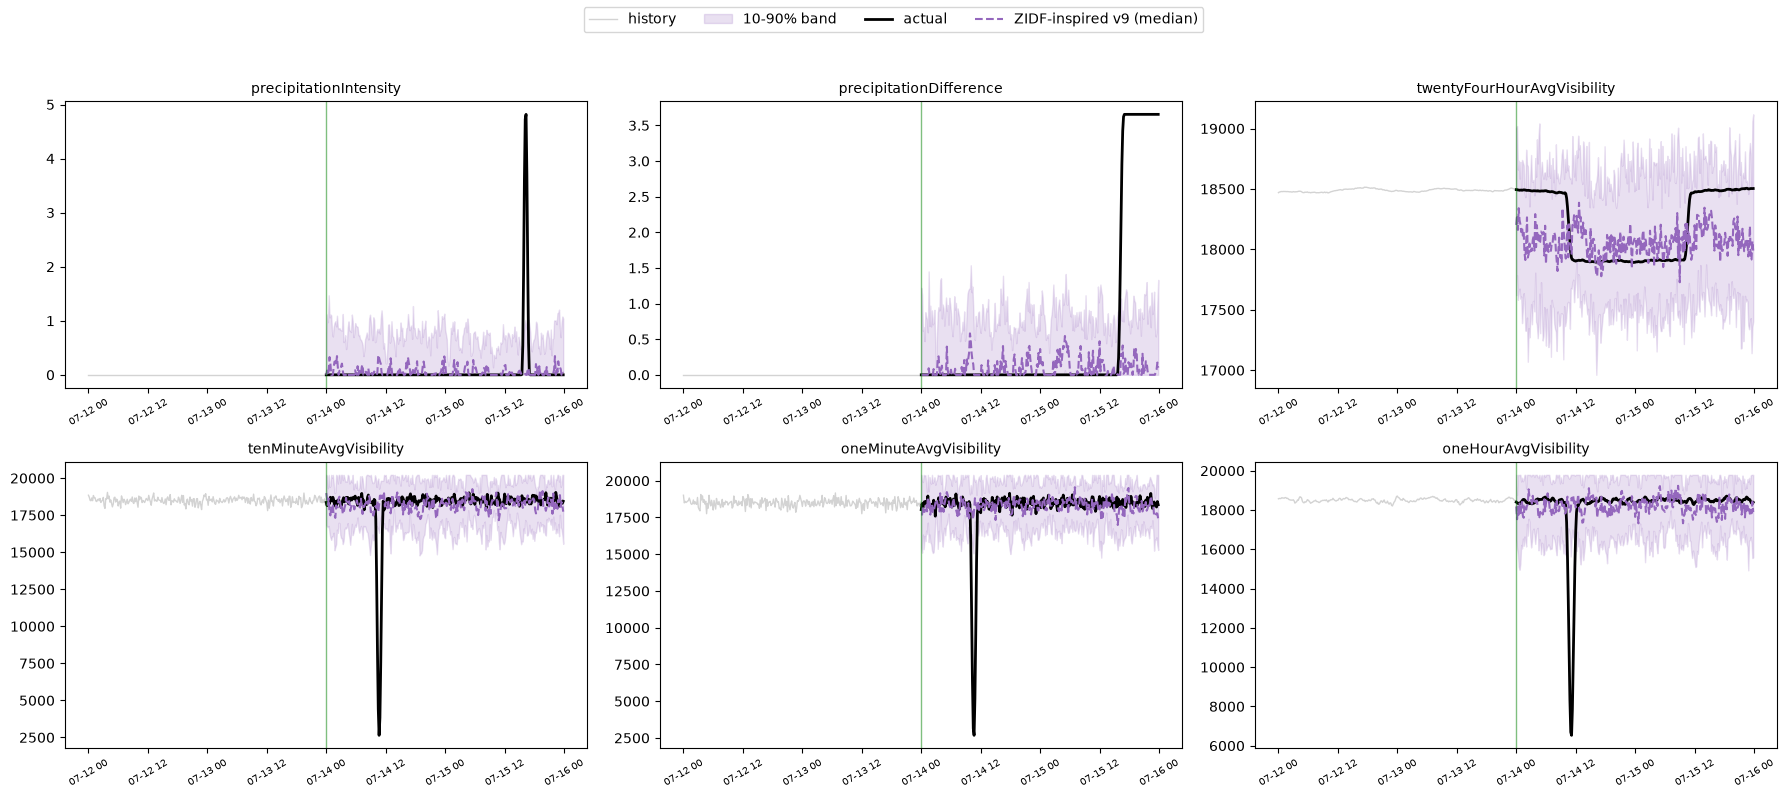

Saved zidf_v9_hard6_plot.png


In [8]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), HARD_PARAMS):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.fill_between(truth.index, all_bands[c][0], all_bands[c][1], color="#9467bd", alpha=0.2, label="10-90% band")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, all_pred[c], color="#9467bd", lw=1.5, ls="--", label="ZIDF-inspired v9 (median)")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=4)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("zidf_v9_hard6_plot.png", dpi=110)
plt.show()
print("Saved zidf_v9_hard6_plot.png")

## 8. Save outputs for the dashboard

In [9]:
fva = pd.DataFrame({"timestamp": truth.index})
for c in HARD_PARAMS:
    fva[f"{c}__actual"] = truth[c].values
    fva[f"{c}__zidf_v9"] = all_pred[c]
    fva[f"{c}__q10"] = all_bands[c][0]
    fva[f"{c}__q90"] = all_bands[c][1]
fva.to_csv("forecast_vs_actual_zidf_v9.csv", index=False)
print("Saved: metrics_zidf_v9.csv, forecast_vs_actual_zidf_v9.csv, zidf_v9_hard6_plot.png")

Saved: metrics_zidf_v9.csv, forecast_vs_actual_zidf_v9.csv, zidf_v9_hard6_plot.png


## 9. Conclusion

Section 6 is the actual verdict. This tests a structurally different hypothesis than every prior
attempt: that sampling diverse trajectories and taking the median can escape the mean-collapse problem
that broke v4 (visibility) and v6/v7 (precipitation) — rather than trying to fix that problem with a
better loss function or a better-matched distribution head. If it doesn't beat DeepAR-hybrid, that
suggests the mean-collapse problem isn't really the binding constraint either — and the more
parsimonious explanation (28 days simply isn't enough history to characterize a handful of rare
events, regardless of mechanism) gets stronger with each additional architecture that's been tried
and failed.